In [3]:
import pandas as pd

rt = pd.read_csv("data/SPRT_LogLin_216.csv")

print("Unique ITEM count:", rt.ITEM.nunique())
print("Min ITEM:", rt.ITEM.min())
print("Max ITEM:", rt.ITEM.max())
print(sorted(rt.ITEM.unique())[:15])
print(sorted(rt.ITEM.unique())[-15:])

Unique ITEM count: 216
Min ITEM: 5
Max ITEM: 220
[np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
[np.int64(206), np.int64(207), np.int64(208), np.int64(209), np.int64(210), np.int64(211), np.int64(212), np.int64(213), np.int64(214), np.int64(215), np.int64(216), np.int64(217), np.int64(218), np.int64(219), np.int64(220)]


In [23]:
rt = pd.read_csv("data/SPRT_LogLin_216.csv")
rt.groupby(["ITEM","condition"]).size().head(10)

ITEM  condition
5     HC           71
      LC           70
      MC           75
6     HC           71
      LC           70
      MC           75
7     HC           71
      LC           70
      MC           75
8     HC           71
dtype: int64

In [22]:
from docx import Document

doc = Document("data/Stimuli_Appendix_format.docx")
table = doc.tables[0]

for i in range(9):  # first 3 triplets
    print(i, table.rows[i].cells[0].text)

0 H: In polluted cities, you can barely breathe the air outside the building. (99%)
1 M: The factory built expensive machines to filter the air outside the building. (31%)
2 L: They suspected there was something wrong with the air outside the building. (0%)
3 
4 H: The soldier decided to quit the army after school. (65%)
5 M: George chose not to join the army after school. (35%)
6 L: The students were learning about the army after school. (0%)
7 
8 H: My sister enjoys poetry, painting, and other forms of art from the past. (92%)


In [ ]:
merged_clean = pd.read_csv("data/bk21_clean_trial_level.csv")
print("Final shape:", merged_clean.shape) # 46,092 = 216 items x 213 participants

Final shape: (46092, 7)


In [12]:
import pandas as pd

stim = pd.read_csv("data/bk21_gpt2_surprisal.csv")

stim.head()

,ITEM,condition,sentence,critical_word,gpt2_s_surprisal
0,5,LC,They suspected there was something wrong with ...,building,2.532531
1,6,LC,The students were learning about the army afte...,school,4.950843
2,7,LC,They hired the consultant because of her knowl...,past,5.727485
3,8,LC,The accountant put all of the old documents in...,home,4.761936
4,9,LC,My father scared away the burglars with his ax...,intimidating,12.410499


In [13]:
stim["gpt2_s_surprisal"].describe()

count    648.000000
mean       6.818118
std        4.241469
min        0.000051
25%        3.622693
50%        6.460167
75%        9.706356
max       20.738806
Name: gpt2_s_surprisal, dtype: float64

In [14]:
stim["gpt2_s_surprisal"].isna().sum()

np.int64(0)

In [16]:
stim.groupby("condition")["gpt2_s_surprisal"].mean()

condition
HC    6.865028
LC    6.846434
MC    6.742893
Name: gpt2_s_surprisal, dtype: float64

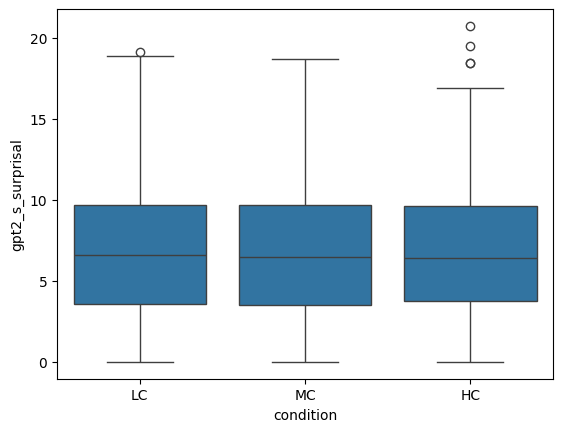

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=stim, x="condition", y="gpt2_s_surprisal")
plt.show()

In [18]:
(stim["sentence"].str.split().str[-1].str.rstrip(".") == stim["critical_word"]).all()

np.True_

In [19]:
stim[stim["ITEM"] == 5]

,ITEM,condition,sentence,critical_word,gpt2_s_surprisal
0,5,LC,They suspected there was something wrong with ...,building,2.532531
280,5,MC,The factory built expensive machines to filter...,building,3.907532
560,5,HC,"In polluted cities, you can barely breathe the...",building,4.762275


In [20]:
trial = pd.read_csv("data/bk21_clean_trial_level.csv")

df = trial.merge(
    stim[["ITEM","condition","gpt2_s_surprisal"]],
    on=["ITEM","condition"],
    how="left"
)

df.head()

,SUB,ITEM,condition,sentence,critical_word,SUM_3RT_trimmed,log_rt,gpt2_s_surprisal
0,1513268790,5,LC,They suspected there was something wrong with ...,building,568.0,6.342121,2.532531
1,1513268790,6,LC,The students were learning about the army afte...,school,719.0,6.577861,4.950843
2,1513268790,7,LC,They hired the consultant because of her knowl...,past,736.0,6.601230,5.727485
3,1513268790,8,LC,The accountant put all of the old documents in...,home,538.0,6.287859,4.761936
4,1513268790,9,LC,My father scared away the burglars with his ax...,intimidating,568.0,6.342121,12.410499


In [21]:
row = stim[stim["ITEM"] == 5]

for _, r in row.iterrows():
    print("\nCondition:", r["condition"])
    print("Sentence:", r["sentence"])
    print("Critical:", r["critical_word"])
    print("Last word from split:", r["sentence"].split()[-1])


Condition: LC
Sentence: They suspected there was something wrong with the air outside the building.
Critical: building
Last word from split: building.

Condition: MC
Sentence: The factory built expensive machines to filter the air outside the building.
Critical: building
Last word from split: building.

Condition: HC
Sentence: In polluted cities, you can barely breathe the air outside the building.
Critical: building
Last word from split: building.


ensure alignment

In [25]:
stim[stim["ITEM"] == 5]

,ITEM,condition,sentence,critical_word,gpt2_s_surprisal
0,5,LC,They suspected there was something wrong with ...,building,2.532531
280,5,MC,The factory built expensive machines to filter...,building,3.907532
560,5,HC,"In polluted cities, you can barely breathe the...",building,4.762275


In [ ]:
rt[rt["ITEM"] == 5][[""]].drop_duplicates()

,condition
0,LC
700,MC
1400,HC


In [27]:
# Inspect ITEM 5 in both files
print("Stimuli:")
print(stim[stim["ITEM"] == 5][["condition","sentence","gpt2_s_surprisal"]])

print("\nRT file conditions:")
print(rt[rt["ITEM"] == 5]["condition"].unique())

Stimuli:
    condition                                           sentence  \
0          LC  They suspected there was something wrong with ...   
280        MC  The factory built expensive machines to filter...   
560        HC  In polluted cities, you can barely breathe the...   

     gpt2_s_surprisal  
0            2.532531  
280          3.907532  
560          4.762275  

RT file conditions:
['LC' 'MC' 'HC']


In [28]:
stim["local_context"] = stim["sentence"].apply(lambda s: " ".join(s.split()[-3:-1]))

stim.groupby("ITEM")["local_context"].nunique().value_counts()

local_context
1    216
Name: count, dtype: int64

In [29]:
pivot = stim.pivot(index="ITEM", columns="condition", values="gpt2_s_surprisal")

pivot["HC_minus_LC"] = pivot["HC"] - pivot["LC"]

pivot["HC_minus_LC"].describe()

count    216.000000
mean       0.018594
std        2.276208
min       -8.050283
25%       -1.128506
50%        0.064831
75%        1.216701
max        6.982697
Name: HC_minus_LC, dtype: float64

In [30]:
stim.groupby("condition")["gpt2_s_surprisal"].std()

condition
HC    4.374190
LC    4.225415
MC    4.140187
Name: gpt2_s_surprisal, dtype: float64